In [1]:
# ============================================================
# CELL 1: Install sentiment analysis library
# ============================================================

# VADER is built specifically for social media text — perfect for titles
!pip install vaderSentiment --quiet

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

# Mount drive and load data
drive.mount('/content/drive')
project_path = '/content/drive/MyDrive/podcast_analytics'
df = pd.read_csv(f'{project_path}/USvideos_cleaned.csv')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi']        = 130
plt.rcParams['figure.facecolor']  = 'white'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print(f"Loaded {len(df):,} videos. Ready for sentiment analysis.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 8.7 MB/s eta 0:00:00
Mounted at /content/drive
Loaded 6,351 videos. Ready for sentiment analysis.


In [2]:
# ============================================================
# CELL 2: Run sentiment scoring on all video titles
# ============================================================

analyzer = SentimentIntensityAnalyzer()

def get_sentiment_scores(title):
    if pd.isna(title) or title == '':
        return 0, 0, 0, 0
    scores = analyzer.polarity_scores(str(title))
    return (scores['pos'], scores['neg'],
            scores['neu'], scores['compound'])

# Apply to every title — compound score is the key metric
# compound ranges from -1.0 (most negative) to +1.0 (most positive)
df[['sent_positive', 'sent_negative',
    'sent_neutral',  'sent_compound']] = df['title_clean'].apply(
    lambda t: pd.Series(get_sentiment_scores(t))
)

# Classify each title into a sentiment category
def classify_sentiment(compound):
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['sent_compound'].apply(classify_sentiment)

# Summary
print("SENTIMENT DISTRIBUTION:")
print("-" * 35)
dist = df['sentiment_label'].value_counts()
total = len(df)
for label, count in dist.items():
    pct = count / total * 100
    bar = '█' * int(pct / 2)
    print(f"  {label:<10} {bar:<25} {count:>5} ({pct:.1f}%)")

print(f"\nAverage compound score: {df['sent_compound'].mean():.3f}")
print(f"Most positive title:")
top_pos = df.loc[df['sent_compound'].idxmax(), 'title_clean']
print(f"  '{top_pos}'")
print(f"\nMost negative title:")
top_neg = df.loc[df['sent_compound'].idxmin(), 'title_clean']
print(f"  '{top_neg}'")

SENTIMENT DISTRIBUTION:
-----------------------------------
  Neutral    ██████████████████████████  3408 (53.7%)
  Positive   █████████████              1730 (27.2%)
  Negative   █████████                  1213 (19.1%)

Average compound score: 0.044
Most positive title:
  'INDIAN STREET FOOD Tour DEEP in PUNJAB, INDIA | BEST STREET FOOD in INDIA and BEST CURRY HEAVEN!'

Most negative title:
  'THIS HAS TO STOP! INSTAGRAM TRENDS I HATED IN 2017 AND NEED TO DIE'


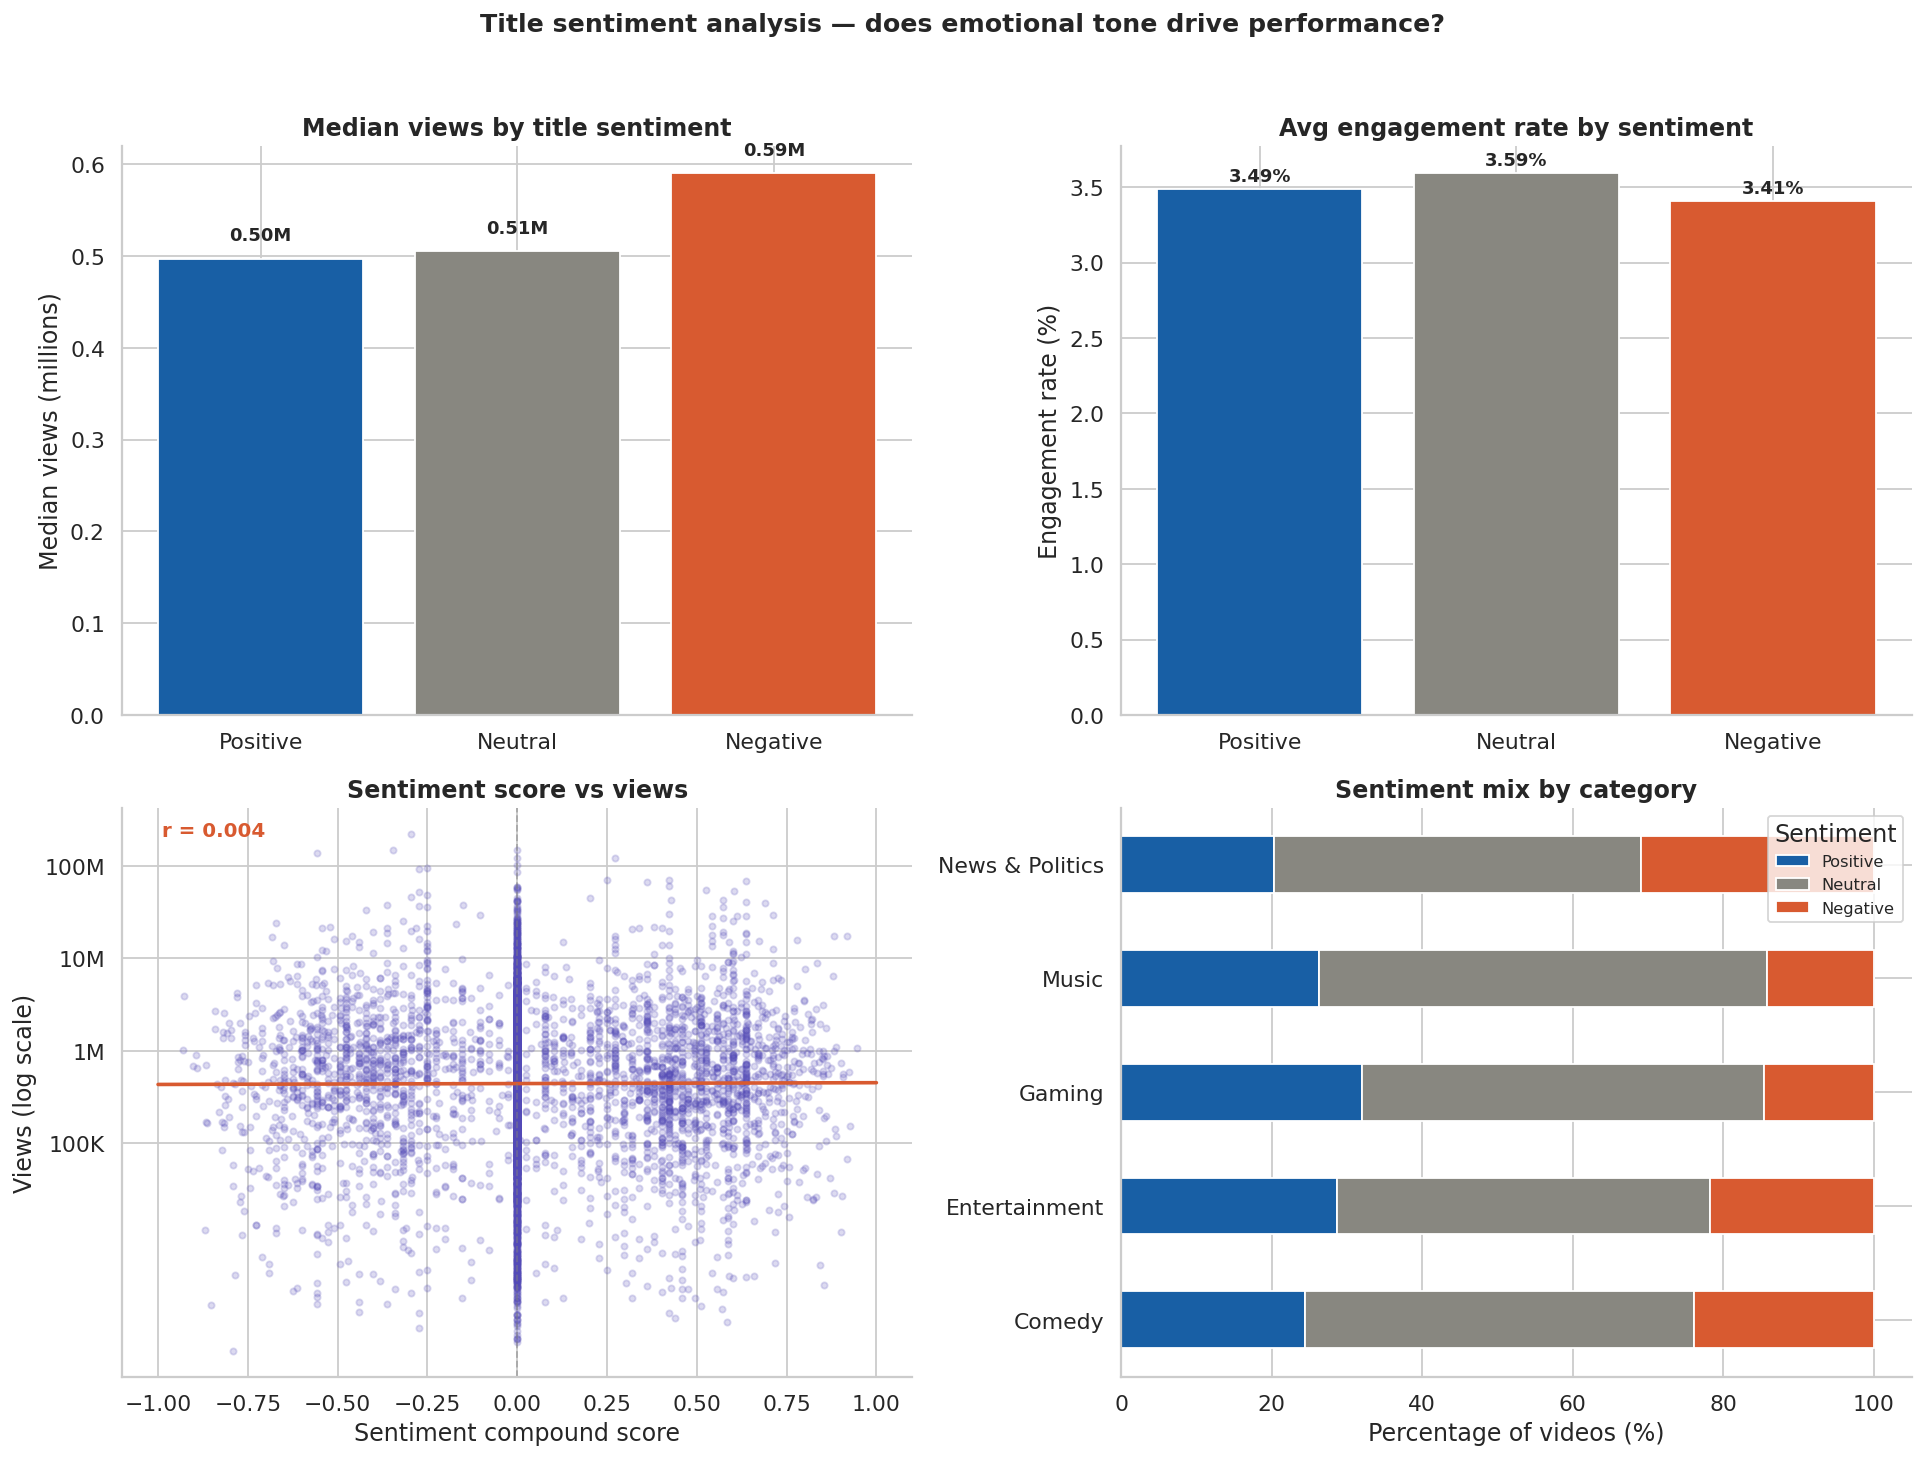


KEY SENTIMENT FINDINGS:
  Positive   median views=0.50M  avg engagement=3.49%
  Neutral    median views=0.51M  avg engagement=3.59%
  Negative   median views=0.59M  avg engagement=3.41%

Correlation (sentiment vs log views): 0.004


In [3]:
# ============================================================
# CELL 3: Does title sentiment drive views and engagement?
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

sent_order  = ['Positive', 'Neutral', 'Negative']
sent_colors = ['#185FA5', '#888780', '#D85A30']

# --- Top left: median views by sentiment ---
sent_views = (df.groupby('sentiment_label')['views']
                .median()
                .reindex(sent_order))
bars = axes[0,0].bar(sent_views.index, sent_views.values / 1e6,
                     color=sent_colors, edgecolor='white')
axes[0,0].set_title('Median views by title sentiment', fontweight='bold')
axes[0,0].set_ylabel('Median views (millions)')
for bar, val in zip(bars, sent_views.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.02,
                   f'{val/1e6:.2f}M',
                   ha='center', fontsize=10, fontweight='bold')

# --- Top right: avg engagement rate by sentiment ---
sent_eng = (df.groupby('sentiment_label')['engagement_rate']
              .mean()
              .reindex(sent_order))
bars2 = axes[0,1].bar(sent_eng.index, sent_eng.values,
                      color=sent_colors, edgecolor='white')
axes[0,1].set_title('Avg engagement rate by sentiment', fontweight='bold')
axes[0,1].set_ylabel('Engagement rate (%)')
for bar, val in zip(bars2, sent_eng.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.05,
                   f'{val:.2f}%',
                   ha='center', fontsize=10, fontweight='bold')

# --- Bottom left: compound score vs views scatter ---
axes[1,0].scatter(df['sent_compound'],
                  np.log10(df['views'] + 1),
                  alpha=0.2, s=12, color='#534AB7')
z = np.polyfit(df['sent_compound'],
               np.log10(df['views'] + 1), 1)
p = np.poly1d(z)
x_line = np.linspace(-1, 1, 100)
axes[1,0].plot(x_line, p(x_line),
               color='#D85A30', linewidth=2)
axes[1,0].set_xlabel('Sentiment compound score')
axes[1,0].set_ylabel('Views (log scale)')
axes[1,0].set_title('Sentiment score vs views', fontweight='bold')
axes[1,0].set_yticks([5, 6, 7, 8])
axes[1,0].set_yticklabels(['100K', '1M', '10M', '100M'])
axes[1,0].axvline(x=0, color='gray', linestyle='--',
                  linewidth=1, alpha=0.5)

corr = df['sent_compound'].corr(np.log10(df['views'] + 1))
axes[1,0].text(0.05, 0.95, f'r = {corr:.3f}',
               transform=axes[1,0].transAxes,
               fontsize=11, color='#D85A30', fontweight='bold')

# --- Bottom right: sentiment breakdown by top categories ---
top_cats = ['Music', 'Entertainment', 'News & Politics',
            'Comedy', 'Gaming']
cat_sent = (df[df['category_name'].isin(top_cats)]
              .groupby(['category_name', 'sentiment_label'])
              .size()
              .unstack(fill_value=0))
cat_sent_pct = cat_sent.div(cat_sent.sum(axis=1), axis=0) * 100

cat_sent_pct[['Positive','Neutral','Negative']].plot(
    kind='barh', stacked=True,
    color=sent_colors,
    ax=axes[1,1], edgecolor='white'
)
axes[1,1].set_title('Sentiment mix by category', fontweight='bold')
axes[1,1].set_xlabel('Percentage of videos (%)')
axes[1,1].set_ylabel('')
axes[1,1].legend(title='Sentiment', fontsize=9)

plt.suptitle('Title sentiment analysis — does emotional tone drive performance?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{project_path}/plot_09_sentiment_analysis.png',
            bbox_inches='tight', dpi=150)
plt.show()

print("\nKEY SENTIMENT FINDINGS:")
for label, views, eng in zip(
        sent_order,
        sent_views.values / 1e6,
        sent_eng.values):
    print(f"  {label:<10} median views={views:.2f}M  "
          f"avg engagement={eng:.2f}%")
print(f"\nCorrelation (sentiment vs log views): {corr:.3f}")

In [4]:
# ============================================================
# CELL 4: Build features for ML model
# ============================================================

from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics         import (classification_report,
                                     confusion_matrix,
                                     accuracy_score)

# Define high engagement: top 33% by engagement rate
threshold = df['engagement_rate'].quantile(0.67)
df['high_engagement'] = (df['engagement_rate'] >= threshold).astype(int)

print(f"Engagement threshold (top 33%): {threshold:.2f}%")
print(f"High engagement videos: {df['high_engagement'].sum():,}")
print(f"Low  engagement videos: {(df['high_engagement']==0).sum():,}")

# Encode day of week as a number
day_map = {'Monday':0,'Tuesday':1,'Wednesday':2,
           'Thursday':3,'Friday':4,'Saturday':5,'Sunday':6}
df['day_encoded'] = df['publish_day_of_week'].map(day_map)

# Encode category as a number
le = LabelEncoder()
df['category_encoded'] = le.fit_transform(
    df['category_name'].fillna('Unknown'))

# Select features — these are what the model learns from
feature_cols = [
    'publish_hour',       # What hour was it published?
    'day_encoded',        # What day of week?
    'publish_month',      # What month?
    'title_length',       # How long is the title?
    'days_to_trend',      # How fast did it trend?
    'category_encoded',   # What category?
    'sent_compound',      # What is the title sentiment?
    'has_comments',       # Are comments enabled?
    'has_ratings',        # Are ratings enabled?
]

X = df[feature_cols].fillna(0)
y = df['high_engagement']

print(f"\nFeatures used: {len(feature_cols)}")
print(f"Total samples: {len(X):,}")
for col in feature_cols:
    print(f"  • {col}")

Engagement threshold (top 33%): 3.98%
High engagement videos: 2,096
Low  engagement videos: 4,255

Features used: 9
Total samples: 6,351
  • publish_hour
  • day_encoded
  • publish_month
  • title_length
  • days_to_trend
  • category_encoded
  • sent_compound
  • has_comments
  • has_ratings


In [5]:
# ============================================================
# CELL 5: Train model and evaluate performance
# ============================================================

# Split data — 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train):,} videos")
print(f"Testing set:  {len(X_test):,} videos")

# Train the Random Forest
model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees
    max_depth=8,         # Prevent overfitting
    random_state=42,     # Reproducible results
    class_weight='balanced'  # Handle class imbalance
)
model.fit(X_train, y_train)

# Evaluate on test set
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel accuracy: {accuracy*100:.1f}%")
print("\nDetailed performance report:")
print(classification_report(
    y_test, y_pred,
    target_names=['Low engagement', 'High engagement']
))

Training set: 5,080 videos
Testing set:  1,271 videos

Model accuracy: 66.3%

Detailed performance report:
                 precision    recall  f1-score   support

 Low engagement       0.81      0.65      0.72       852
High engagement       0.49      0.69      0.58       419

       accuracy                           0.66      1271
      macro avg       0.65      0.67      0.65      1271
   weighted avg       0.71      0.66      0.67      1271



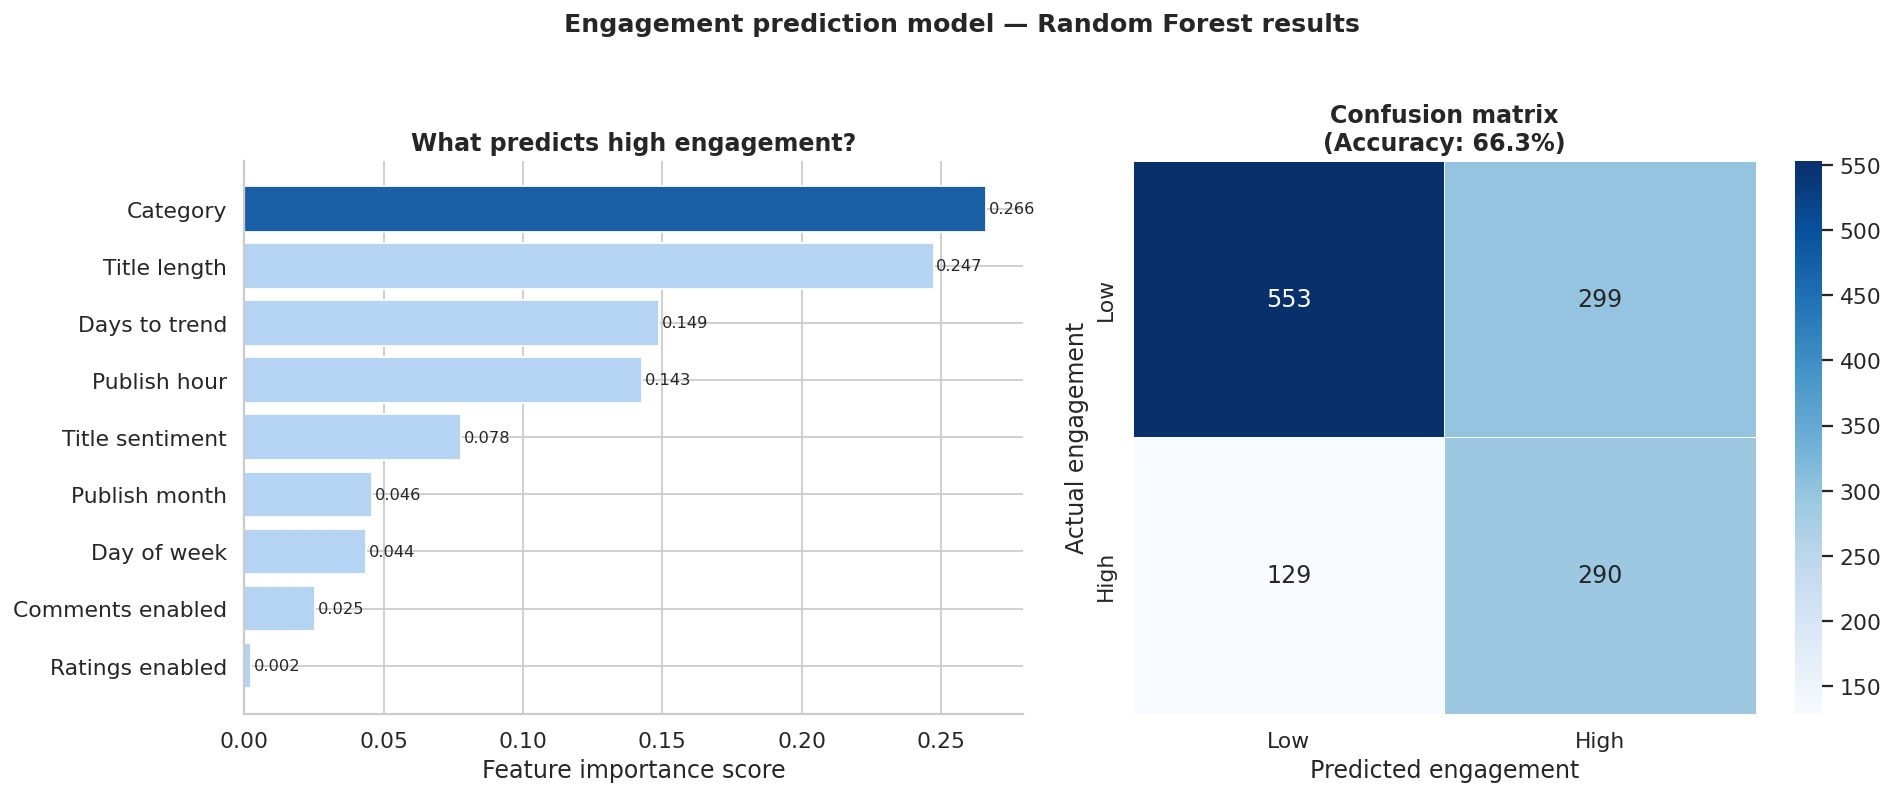


FEATURE IMPORTANCE RANKING:
----------------------------------------
  Category               ██████████████████████████ 0.266
  Title length           ████████████████████████ 0.247
  Days to trend          ██████████████       0.149
  Publish hour           ██████████████       0.143
  Title sentiment        ███████              0.078
  Publish month          ████                 0.046
  Day of week            ████                 0.044
  Comments enabled       ██                   0.025
  Ratings enabled                             0.002


In [6]:
# ============================================================
# CELL 6: Visualise model results
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left: feature importance (what actually drives engagement?) ---
importances = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

feature_labels = {
    'publish_hour':    'Publish hour',
    'day_encoded':     'Day of week',
    'publish_month':   'Publish month',
    'title_length':    'Title length',
    'days_to_trend':   'Days to trend',
    'category_encoded':'Category',
    'sent_compound':   'Title sentiment',
    'has_comments':    'Comments enabled',
    'has_ratings':     'Ratings enabled'
}
importances.index = [feature_labels[i] for i in importances.index]

colors = ['#185FA5' if v == importances.max()
          else '#B5D4F4' for v in importances.values]

axes[0].barh(importances.index, importances.values,
             color=colors, edgecolor='white')
axes[0].set_title('What predicts high engagement?',
                  fontweight='bold')
axes[0].set_xlabel('Feature importance score')
axes[0].axvline(x=0, color='gray', linewidth=0.5)

for i, (val, name) in enumerate(
        zip(importances.values, importances.index)):
    axes[0].text(val + 0.001, i,
                 f'{val:.3f}', va='center', fontsize=9)

# --- Right: confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues', ax=axes[1],
    xticklabels=['Low', 'High'],
    yticklabels=['Low', 'High'],
    linewidths=0.5
)
axes[1].set_title(f'Confusion matrix\n(Accuracy: {accuracy*100:.1f}%)',
                  fontweight='bold')
axes[1].set_xlabel('Predicted engagement')
axes[1].set_ylabel('Actual engagement')

plt.suptitle('Engagement prediction model — Random Forest results',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{project_path}/plot_10_ml_model.png',
            bbox_inches='tight', dpi=150)
plt.show()

print("\nFEATURE IMPORTANCE RANKING:")
print("-" * 40)
for feat, score in importances.sort_values(
        ascending=False).items():
    bar = '█' * int(score * 100)
    print(f"  {feat:<22} {bar:<20} {score:.3f}")

In [7]:
# ============================================================
# CELL 7: Save final dataset with all new columns to Drive
# ============================================================

# Save enriched dataset with sentiment and ML columns
df.to_csv(f'{project_path}/USvideos_final.csv', index=False)

print("Final enriched dataset saved!")
print(f"\nNew columns added in Phase 7:")
new_cols = ['sent_positive', 'sent_negative', 'sent_neutral',
            'sent_compound', 'sentiment_label',
            'high_engagement', 'day_encoded', 'category_encoded']
for col in new_cols:
    print(f"  • {col}")

print(f"\nTotal columns in final dataset: {df.shape[1]}")
print(f"\nPhase 7 plots saved to Drive:")
print(f"  • plot_09_sentiment_analysis.png")
print(f"  • plot_10_ml_model.png")
print("\nPhase 7 complete!")

Final enriched dataset saved!

New columns added in Phase 7:
  • sent_positive
  • sent_negative
  • sent_neutral
  • sent_compound
  • sentiment_label
  • high_engagement
  • day_encoded
  • category_encoded

Total columns in final dataset: 38

Phase 7 plots saved to Drive:
  • plot_09_sentiment_analysis.png
  • plot_10_ml_model.png

Phase 7 complete!
